In [1]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, END, StateGraph, MessagesState

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from dotenv import load_dotenv
from langchain.messages import RemoveMessage

load_dotenv()

True

In [2]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [3]:
def call_model(state:MessagesState):
    response=llm.invoke(state["messages"])
    return {"messages":[response]}

def delete_old_messages(state:MessagesState):
    msgs=state["messages"]

    if len(msgs)>=10:
        to_remove=msgs[:6]
        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}
    return {}

In [4]:
graph=StateGraph(MessagesState)

graph.add_node("call_model",call_model)
graph.add_node("delete_old_messages",delete_old_messages)

graph.add_edge(START,"call_model")
graph.add_edge("call_model","delete_old_messages")

graph=graph.compile(checkpointer=InMemorySaver())

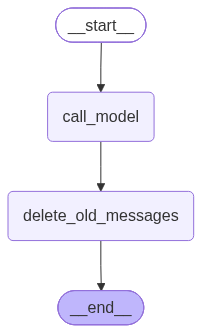

In [5]:
graph